# 03 - One year of PV and load profiles, and a screening of the feeder voltage

Notebook 02 looked at snapshots: it fixed the TR1 tap at +4.375 % so that the feeder
without PV stays inside 0.95 to 1.05 pu at every load level of the brochure's daily
profiles, and showed that the 6.44 MW of PV on feeder 1 push the far buses above 1.05 pu
whenever full sun meets a light load. Snapshots cannot say *how often* that happens. To
compare voltage-control options over a whole year rather than at one instant, a year of
time series is needed: PV output of each unit and load of each sector at every 15-minute
step, 35,040 steps in all.

No measured data are used. The profiles are synthetic, generated by `profiles.py` (next to
this notebook) from closed-form solar geometry, a seeded random cloud model and the
brochure's own daily load shapes (CIGRE TB 575, Figure 6.4, in the data file as
`load_profiles`), so that the whole study is reproducible from one seed with no downloads.
The models are deliberately simple: they are not a weather reconstruction of any year or
place, but a plausible, reproducible mix of clear days, broken-cloud days, overcast days,
weekends and seasons on which control strategies can be compared like for like.

This notebook builds and stores the profiles, shows what they contain, and then runs a
screening power flow of every step of the year with the PV units at unity power factor
(no voltage control at all). The screening gives the number of hours above 1.05 pu that
the controllers of the next notebook are measured against, and selects two days for daily
plots: the worst day and a typical sunny day.

Steps:

1. The load model: brochure daily shapes, seasonal and weekly factors, noise.
2. The PV model: clear-sky geometry, Markov cloud chain, spatial diversity.
3. Save the year to `profiles_2023.h5` and print its statistics.
4. Year overview: heatmaps and daily series.
5. Screening at unity power factor: one power flow per step, hours above 1.05 pu, worst and typical day.
6. Save the selected days and the screening series.
7. Summary.

In [1]:
# Paths: this notebook runs from notebooks/, the modules live in src/ and every
# generated file in results/, so the working directory is moved there once.
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    sys.path.insert(0, os.path.abspath(os.path.join(os.pardir, "src")))
    os.makedirs(os.path.join(os.pardir, "results"), exist_ok=True)
    os.chdir(os.path.join(os.pardir, "results"))

import json, math, time
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import opendssdirect as dss

import cigre_dss as cd
import profiles as pf

TR1_TAP = 4.375                 # % on the 20 kV side, fixed in notebook 02
YEAR, SEED, LAT = 2023, 0, 50.0
PV_BUSES = list(cd.PV_KW)       # 3 .. 11
PV_TOTAL_KW = sum(cd.PV_KW.values())
STEP_MIN = 15; dt_h = STEP_MIN / 60

d = cd.load_data()
peak_res = sum(ld["residential"]["P_kW_derived"] or 0 for ld in d["loads"])
peak_ci = sum(ld["commercial_industrial"]["P_kW_derived"] or 0 for ld in d["loads"])
def total_pu(res_pu, ci_pu):
    return (peak_res * res_pu + peak_ci * ci_pu) / (peak_res + peak_ci)

plt.rcParams.update({"font.size": 10, "axes.titlesize": 10, "axes.labelsize": 10,
                     "legend.fontsize": 9, "xtick.labelsize": 9, "ytick.labelsize": 9})
def legend_below(ax, ncol=3, dy=-0.15):
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, dy), ncol=ncol, frameon=False)
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
MONTH_START = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
MONTH_DATES = [pd.Timestamp(YEAR, m, 1) for m in range(1, 13)]

print("opendssdirect", dss.__version__, "| pandas", pd.__version__, "| numpy", np.__version__)
print(f"TR1 tap +{TR1_TAP} %, {len(PV_BUSES)} PV units, {PV_TOTAL_KW/1e3:.2f} MW, kVA = 1.1 x Pmpp, unity pf")
print(f"sector peaks: residential {peak_res/1e3:.2f} MW, commercial/industrial {peak_ci/1e3:.2f} MW")

opendssdirect 0.9.4 | pandas 2.3.3 | numpy 2.4.6
TR1 tap +4.375 %, 9 PV units, 6.44 MW, kVA = 1.1 x Pmpp, unity pf
sector peaks: residential 33.57 MW, commercial/industrial 11.17 MW


## 1. The load model

**Time base.** The year 2023 at 15-minute steps, $T = 35\,040$ steps. Time stamps are local
*solar* time of the site (no time zone, no daylight-saving shift, no equation of time), so
12:00 is solar noon on every day. The calendar is that of 2023 (1 January is a Sunday), which
is what fixes the weekends.

**Daily shapes.** The brochure gives one daily profile per sector, residential and
commercial/industrial, in 30-minute steps and in pu of the node peak apparent power
(Figure 6.4). They are read from the data file, interpolated linearly to 15 minutes and
repeated every day of the year. Three multiplicative factors then turn the repeated day
into a year:

$$
\ell_\mathrm{sec}(t) = \frac{\tilde\ell_\mathrm{sec}(t)}{\max_t \tilde\ell_\mathrm{sec}(t)},
\qquad
\tilde\ell_\mathrm{sec}(t) = g_\mathrm{sec}(h)\; s_\mathrm{sec}(n)\; w_\mathrm{sec}(d)\; \bigl(1 + \varepsilon(t)\bigr),
$$

where $g_\mathrm{sec}(h)$ is the interpolated brochure shape at hour of day $h$,

$$
s_\mathrm{res}(n) = 1 + 0.15\cos\!\left(\frac{2\pi (n-15)}{365}\right), \qquad
s_\mathrm{ci}(n) = 1 + 0.05\cos\!\left(\frac{2\pi (n-15)}{365}\right)
$$

is the seasonal factor at day of year $n$ (maximum on 15 January, winter high and summer low,
stronger for households), $w_\mathrm{sec}(d)$ is the weekday/weekend factor (Saturday and
Sunday: residential 1.05, commercial/industrial 0.60, otherwise 1), and $\varepsilon(t)$ is
Gaussian noise smoothed with a 1-hour moving average and scaled to a standard deviation of
3 %. The product is clipped to at least 0.05 and normalised so that the annual maximum of
each sector is exactly 1.0, since the kW and kvar of Table 6.15 are the sector peaks and
`cigre_dss.scale_loads` multiplies those values by the profile. The two sectors are scaled
separately, P and Q together, because the brochure profiles are in pu of apparent power.

The figure shows (a) the two brochure shapes and their total weighted by the sector peak
MW, i.e. the total load of the network in pu of its peak; (b) the seasonal factor of each
sector together with the daily product of seasonal and weekly factors, whose sawtooth is
the weekend; (c) one winter week and (d) one summer week of the two generated series,
Monday to Sunday.

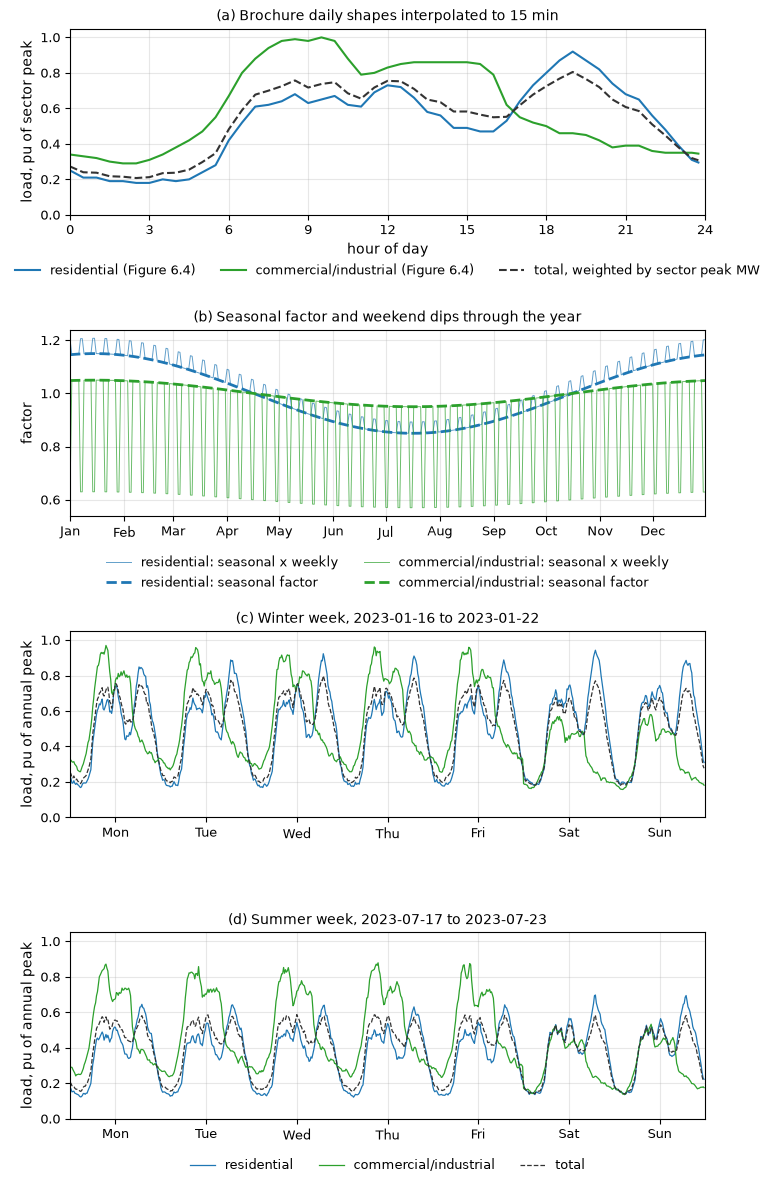

brochure shapes: residential min 0.18 at 2.50 h, max 1.00 at 19.0 h; commercial/industrial min 0.29, max 1.00 at 9.5 h
total load of the brochure day: 0.207 to 0.805 pu of peak


In [2]:
loads = pf.load_profiles(year=YEAR, step_min=STEP_MIN, seed=SEED)
shapes = pf.daily_shapes(step_min=STEP_MIN)
h = np.arange(0, 24, dt_h)
doy = np.arange(1, 366)
days = pd.date_range(f"{YEAR}-01-01", periods=365, freq="D")
wk = np.where(days.dayofweek >= 5, 1.0, 0.0)

fig, axes = plt.subplots(4, 1, figsize=(8, 12))
ax = axes[0]
ax.plot(h, shapes["residential"], color="tab:blue", label="residential (Figure 6.4)")
ax.plot(h, shapes["commercial_industrial"], color="tab:green", label="commercial/industrial (Figure 6.4)")
ax.plot(h, total_pu(shapes["residential"], shapes["commercial_industrial"]), color="0.2", ls="--",
        label="total, weighted by sector peak MW")
ax.set_xlim(0, 24); ax.set_xticks(range(0, 25, 3)); ax.set_ylim(0, 1.05)
ax.set_xlabel("hour of day"); ax.set_ylabel("load, pu of sector peak"); ax.grid(alpha=0.3)
ax.set_title("(a) Brochure daily shapes interpolated to 15 min")
legend_below(ax, ncol=3, dy=-0.2)

ax = axes[1]
for sec, c, lab in (("residential", "tab:blue", "residential"), ("commercial_industrial", "tab:green", "commercial/industrial")):
    s = pf.seasonal_factor(doy, sec)
    ax.plot(doy, s * np.where(wk > 0, pf.WEEKEND[sec], 1.0), color=c, lw=0.7, alpha=0.7, label=f"{lab}: seasonal x weekly")
    ax.plot(doy, s, color=c, lw=2, ls="--", label=f"{lab}: seasonal factor")
ax.set_xlim(1, 365); ax.set_xticks(MONTH_START); ax.set_xticklabels(MONTHS)
ax.set_ylabel("factor"); ax.grid(alpha=0.3)
ax.set_title("(b) Seasonal factor and weekend dips through the year")
legend_below(ax, ncol=2, dy=-0.15)

for ax, (start, lab) in zip(axes[2:], ((f"{YEAR}-01-16", "(c) Winter week"), (f"{YEAR}-07-17", "(d) Summer week"))):
    w = loads.loc[start:str(pd.Timestamp(start) + pd.Timedelta(days=6, hours=23, minutes=45))]
    x = np.arange(len(w)) * dt_h / 24
    ax.plot(x, w.residential, color="tab:blue", lw=0.9, label="residential")
    ax.plot(x, w.commercial_industrial, color="tab:green", lw=0.9, label="commercial/industrial")
    ax.plot(x, total_pu(w.residential.values, w.commercial_industrial.values), color="0.2", lw=0.9, ls="--", label="total")
    ax.set_xlim(0, 7); ax.set_xticks(np.arange(7) + 0.5)
    ax.set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]); ax.set_ylim(0, 1.05)
    ax.set_ylabel("load, pu of annual peak"); ax.grid(alpha=0.3)
    ax.set_title(f"{lab}, {start} to {(pd.Timestamp(start) + pd.Timedelta(days=6)).date()}")
legend_below(axes[3], ncol=3, dy=-0.15)
plt.tight_layout(); plt.show()

print(f"brochure shapes: residential min {shapes['residential'].min():.2f} at {h[shapes['residential'].argmin()]:.2f} h, "
      f"max 1.00 at {h[shapes['residential'].argmax()]:.1f} h; commercial/industrial min {shapes['commercial_industrial'].min():.2f}, "
      f"max 1.00 at {h[shapes['commercial_industrial'].argmax()]:.1f} h")
tot = total_pu(shapes["residential"], shapes["commercial_industrial"])
print(f"total load of the brochure day: {tot.min():.3f} to {tot.max():.3f} pu of peak")

## 2. The PV model

The site latitude is $\varphi = 50^\circ$ N, a central-European value in keeping with the
brochure's European network. All nine units are treated as south-facing arrays at a fixed
tilt $\beta = 30^\circ$.

**Clear-sky part.** Plain solar geometry gives the declination, hour angle and solar
elevation,

$$
\delta = 23.45^\circ \sin\!\left(\frac{2\pi(284 + n)}{365}\right), \qquad
\omega = 15^\circ/\mathrm{h}\,(t_\mathrm{solar} - 12\,\mathrm{h}), \qquad
\sin e = \sin\varphi \sin\delta + \cos\varphi \cos\delta \cos\omega ,
$$

with $n$ the day of the year. The clear-sky irradiance on a horizontal surface follows the
Haurwitz model, the "1000 W/m$^2$ times $\sin e$" rule with an exponential air-mass
attenuation (air mass $\approx 1/\sin e$):

$$
G_\mathrm{clear} = 1098\,\mathrm{W/m^2}\; \sin e \; \exp\!\left(-\frac{0.059}{\sin e}\right).
$$

Only the beam component is projected onto the tilted plane. For a south-facing plane the
incidence angle $\theta$ is the zenith angle seen from an *effective latitude*
$\varphi - \beta$, so

$$
\cos\theta = \sin(\varphi-\beta)\sin\delta + \cos(\varphi-\beta)\cos\delta\cos\omega, \qquad
G_\mathrm{poa} = 1098\,\max(\cos\theta, 0)\,\exp\!\left(-\frac{0.059}{\sin e}\right) \quad (e > 0).
$$

The per-unit clear-sky output is $p_\mathrm{cs} = \min(G_\mathrm{poa}/1000\,\mathrm{W/m^2},\,1)$,
because `cigre_dss.add_pv` quotes $P_\mathrm{mpp}$ at 1 kW/m$^2$ with no temperature or
efficiency derating. Diffuse irradiance is ignored; the missing few per cent are absorbed
in the clearness index below.

**Cloud part.** A clearness index $k(t) \in [0, 1]$ multiplies the clear-sky output,
$p_\mathrm{PV}(t) = p_\mathrm{cs}(t)\,k(t)$. The sky is in one of two states, *clear* or
*cloudy*, that evolve as a Markov chain with one transition per step. The stationary cloudy
fraction varies with the season,

$$
\pi_\mathrm{cloudy}(n) = 0.60 + 0.20 \cos\!\left(\frac{2\pi (n - 15)}{365}\right)
\qquad (\text{about } 0.80 \text{ in January}, 0.40 \text{ in July}),
$$

and the mean length of a clear spell is 3 h, which fixes
$P(\mathrm{clear}\to\mathrm{clear}) = 1 - \Delta t / 3\,\mathrm{h}$;
$P(\mathrm{cloudy}\to\mathrm{cloudy})$ then follows from the stationary fraction. In the
clear state $k = 0.92 - 0.03\,|\mathcal{N}(0,1)|$ (the Haurwitz model overestimates measured
clear-sky irradiance by a few per cent, and some haze is always present). In the cloudy
state $k$ is a fresh $\mathrm{Beta}(2, 4)$ draw $b_t$ at each step (mean 0.33), passed
through a first-order smoother $k_t = 0.5\,k_{t-1} + 0.5\,b_t$, except that with
probability 0.15 per step the smoother is bypassed: those are the fast ramps of a cloud
edge passing over the array.

**Spatial diversity.** The nine units are a few kilometres apart and see the same sky but
not the same cloud at the same instant. Each unit $i$ gets its own factor
$1 + 0.05\,u_i(t)$, with $u_i$ an independent unit-variance AR(1) process ($\rho = 0.8$)
clipped to $[-1, 1]$, i.e. at most $\pm 5$ % between units.

The figure shows (a) the clear-sky envelope $p_\mathrm{cs}$ on three days; (b) a clear
summer day and (c) a cloudy summer day with all nine units as thin lines, their mean, and
the envelope; (d) the monthly mean daily energy of the mean unit against the clear-sky
value. The clear day is the June-to-August day with the largest PV energy; the cloudy day
is the summer day whose energy is closest to 40 % of it, so that both sun and cloud are
visible.

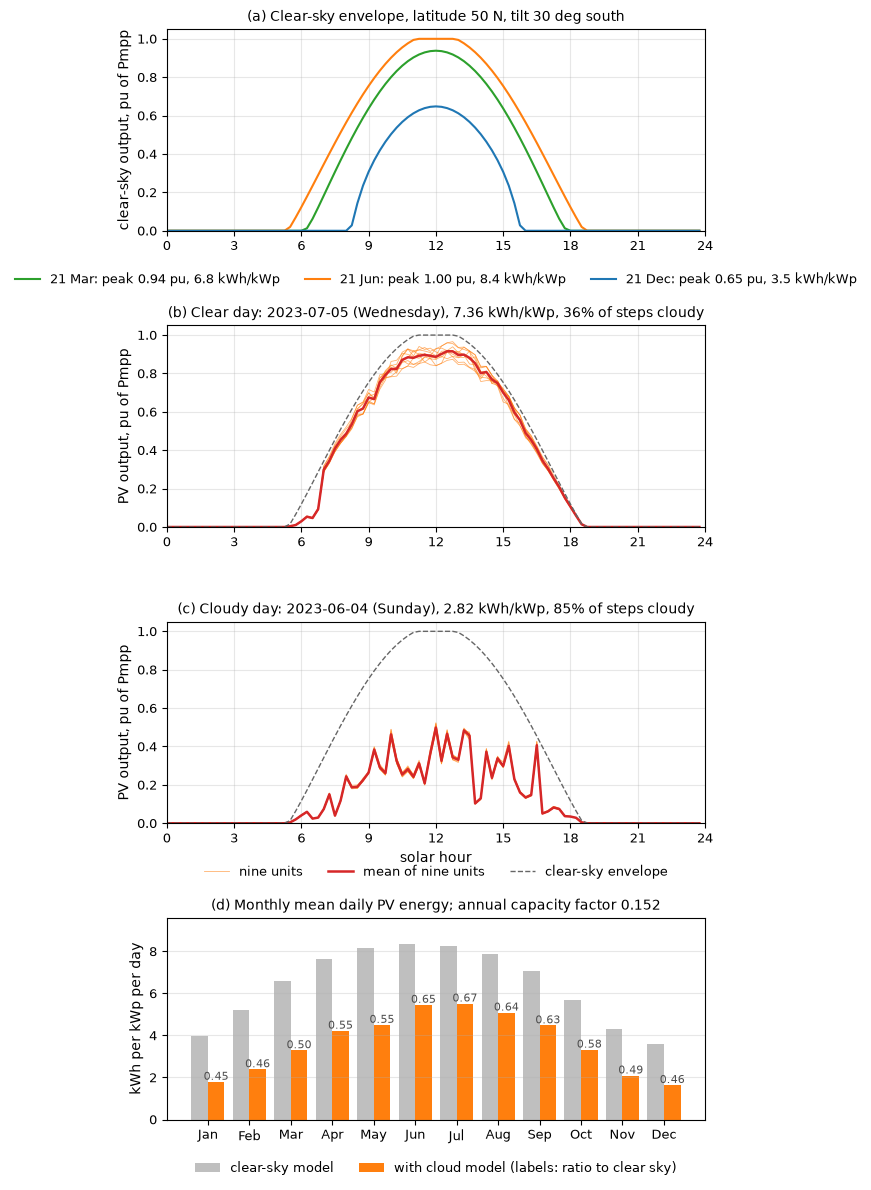

clear day 2023-07-05 (7.36 kWh/kWp), cloudy day 2023-06-04 (2.82 kWh/kWp)
monthly mean daily PV energy, kWh/kWp: Jan 1.79, Feb 2.39, Mar 3.29, Apr 4.22, May 4.50, Jun 5.45, Jul 5.51, Aug 5.08, Sep 4.47, Oct 3.32, Nov 2.09, Dec 1.64


In [3]:
pv_single, parts = pf.pv_profile(year=YEAR, lat_deg=LAT, step_min=STEP_MIN, seed=SEED, return_parts=True)
pv = pf.pv_profiles(n_units=len(PV_BUSES), names=PV_BUSES, year=YEAR, lat_deg=LAT, step_min=STEP_MIN, seed=SEED)
pv_mean = pv.mean(axis=1)
daily = pv_mean.resample("D").sum() * dt_h                       # kWh per kWp per day
summer = daily[(daily.index.month >= 6) & (daily.index.month <= 8)]
DAY_CLEAR = summer.idxmax().date()
DAY_CLOUDY = (summer - 0.4 * summer.max()).abs().idxmin().date()
cf = pv.values.mean()

fig, axes = plt.subplots(4, 1, figsize=(8, 12))
ax = axes[0]
for day, c in ((f"{YEAR}-03-21", "tab:green"), (f"{YEAR}-06-21", "tab:orange"), (f"{YEAR}-12-21", "tab:blue")):
    idx = pd.date_range(day, periods=int(24 / dt_h), freq=f"{STEP_MIN}min")
    cs = pf.clear_sky_pu(idx, LAT)
    ax.plot(h, cs, color=c, label=f"{pd.Timestamp(day).strftime('%d %b')}: peak {cs.max():.2f} pu, {cs.sum() * dt_h:.1f} kWh/kWp")
ax.set_xlim(0, 24); ax.set_xticks(range(0, 25, 3)); ax.set_ylim(0, 1.05)
ax.set_ylabel("clear-sky output, pu of Pmpp"); ax.grid(alpha=0.3)
ax.set_title(f"(a) Clear-sky envelope, latitude {LAT:.0f} N, tilt {pf.TILT_DEG:.0f} deg south")
legend_below(ax, ncol=3, dy=-0.15)

for ax, day, lab in zip(axes[1:3], (DAY_CLEAR, DAY_CLOUDY), ("(b) Clear day", "(c) Cloudy day")):
    p = pv.loc[str(day)]
    for j, b in enumerate(PV_BUSES):
        ax.plot(h, p[b], lw=0.6, color="tab:orange", alpha=0.6, label="nine units" if j == 0 else None)
    ax.plot(h, p.mean(axis=1), lw=1.8, color="tab:red", label="mean of nine units")
    ax.plot(h, parts.loc[str(day), "clear_sky"], lw=1.0, ls="--", color="0.4", label="clear-sky envelope")
    ax.set_xlim(0, 24); ax.set_xticks(range(0, 25, 3)); ax.set_ylim(0, 1.05)
    ax.set_ylabel("PV output, pu of Pmpp"); ax.grid(alpha=0.3)
    ax.set_title(f"{lab}: {day} ({pd.Timestamp(day).day_name()}), {p.mean(axis=1).sum() * dt_h:.2f} kWh/kWp, "
                 f"{parts.loc[str(day), 'cloudy'].mean():.0%} of steps cloudy")
legend_below(axes[2], ncol=3, dy=-0.15)
axes[2].set_xlabel("solar hour")

m_pv = pv_mean.resample("ME").sum() * dt_h / pv_mean.resample("ME").count() * (24 / dt_h)
m_cs = parts.clear_sky.resample("ME").sum() * dt_h / parts.clear_sky.resample("ME").count() * (24 / dt_h)
ax = axes[3]
x = np.arange(12)
ax.bar(x - 0.2, m_cs.values, 0.4, color="0.75", label="clear-sky model")
ax.bar(x + 0.2, m_pv.values, 0.4, color="tab:orange", label="with cloud model (labels: ratio to clear sky)")
for i in range(12):
    ax.text(x[i] + 0.2, m_pv.values[i] + 0.1, f"{m_pv.values[i] / m_cs.values[i]:.2f}", ha="center", fontsize=8, color="0.3")
ax.set_xticks(x); ax.set_xticklabels(MONTHS); ax.set_ylabel("kWh per kWp per day"); ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, m_cs.max() * 1.15)
ax.set_title(f"(d) Monthly mean daily PV energy; annual capacity factor {cf:.3f}")
legend_below(ax, ncol=2, dy=-0.15)
plt.tight_layout(); plt.show()

print(f"clear day {DAY_CLEAR} ({summer.max():.2f} kWh/kWp), cloudy day {DAY_CLOUDY} ({summer[str(DAY_CLOUDY)]:.2f} kWh/kWp)")
print("monthly mean daily PV energy, kWh/kWp:", ", ".join(f"{m} {v:.2f}" for m, v in zip(MONTHS, m_pv.values)))

## 3. Save the year and its statistics

The two load columns of step 1 and the nine PV columns of step 2 are the complete year,
all derived from `seed = 0`. They are written to a single HDF5 file `profiles_2023.h5`
with the datasets `time` (epoch seconds, solar time), `pv` (T by 9, one column per PV
bus), `res` and `com`; pandas' own HDF writer needs pytables, which is not installed, so
`profiles.py` uses h5py directly. The file is re-read to verify the round trip, and the
statistics that characterise the year are printed.

In [4]:
t0 = time.perf_counter()
pf.save_profiles("profiles_2023.h5", pv, loads,
                 attrs=dict(year=YEAR, seed=SEED, lat_deg=LAT, step_min=STEP_MIN,
                            pv_buses=PV_BUSES, pv_kw=[cd.PV_KW[b] for b in PV_BUSES]))
pv_r, loads_r, attrs = pf.load_profiles_from("profiles_2023.h5")
assert np.allclose(pv_r.values, pv.values, atol=1e-6) and np.allclose(loads_r.values, loads.values, atol=1e-6)
assert list(pv_r.columns) == PV_BUSES and pv_r.index.equals(pv.index)
print(f"profiles_2023.h5 written and re-read in {time.perf_counter() - t0:.2f} s; attributes: {attrs}")

print(f"\ntime index: {pv.index[0]} .. {pv.index[-1]}, {len(pv)} steps of {STEP_MIN} min")
print(f"pv: {pv.shape}, loads: {loads.shape}")
print("\nPV (pu of Pmpp)")
print(f"  annual capacity factor            {cf:.3f}  ({cf * 8760:.0f} kWh per kWp per year)")
print(f"  clear-sky capacity factor         {parts.clear_sky.mean():.3f}  (cloud model removes {1 - cf / parts.clear_sky.mean():.0%})")
print(f"  share of steps in the cloudy state {parts.cloudy.mean():.2f}; annual maximum {pv.values.max():.3f} pu")
print(f"  daily energy: mean {daily.mean():.2f}, max {daily.max():.2f} kWh/kWp (on {daily.idxmax().date()})")
print(f"  max spread between units at one step {np.max(pv.max(axis=1) - pv.min(axis=1)):.3f} pu")
print("\nLoad (pu of annual peak)")
for c in loads.columns:
    x = loads[c]
    print(f"  {c:22s} load factor {x.mean():.3f}, min {x.min():.3f}, max {x.max():.3f}, "
          f"peak on {x.idxmax()}; weekend/weekday mean ratio {x[x.index.dayofweek >= 5].mean() / x[x.index.dayofweek < 5].mean():.2f}")
e_pv = (pv.values * np.array([cd.PV_KW[b] for b in PV_BUSES])).sum() * dt_h / 1e3
e_ld = (loads.residential.values * peak_res + loads.commercial_industrial.values * peak_ci).sum() * dt_h / 1e3
print(f"\nannual energy: PV {e_pv:.0f} MWh ({PV_TOTAL_KW / 1e3:.2f} MW installed), "
      f"all loads {e_ld:.0f} MWh ({(peak_res + peak_ci) / 1e3:.1f} MW peak, dominated by the lumped loads at buses 1 and 12)")

profiles_2023.h5 written and re-read in 0.08 s; attributes: {'lat_deg': 50.0, 'pv_buses': [3, 4, 5, 6, 7, 8, 9, 10, 11], 'pv_kw': [690, 690, 680, 680, 740, 740, 740, 740, 740], 'seed': 0, 'step_min': 15, 'year': 2023}

time index: 2023-01-01 00:00:00 .. 2023-12-31 23:45:00, 35040 steps of 15 min
pv: (35040, 9), loads: (35040, 2)

PV (pu of Pmpp)
  annual capacity factor            0.152  (1333 kWh per kWp per year)
  clear-sky capacity factor         0.267  (cloud model removes 43%)
  share of steps in the cloudy state 0.61; annual maximum 0.966 pu
  daily energy: mean 3.65, max 7.36 kWh/kWp (on 2023-07-05)
  max spread between units at one step 0.092 pu

Load (pu of annual peak)
  residential            load factor 0.447, min 0.120, max 1.000, peak on 2023-02-04 19:00:00; weekend/weekday mean ratio 1.05
  commercial_industrial  load factor 0.479, min 0.136, max 1.000, peak on 2023-02-07 09:30:00; weekend/weekday mean ratio 0.60

annual energy: PV 8586 MWh (6.44 MW installed), all load

## 4. Year overview

Three heatmaps with the day of the year on the vertical axis and the solar hour on the
horizontal axis: (a) the PV output, mean of the nine units, where the daylight envelope
widens towards midsummer and the cloudy-state streaks are darker; (b) the residential
load with the daily double peak of the brochure shape (morning and 19:00), the winter to
summer swing and the slightly higher weekends as a faint 7-day stripe; (c) the
commercial/industrial load with its working-hours block and the weekend drop to 60 %
as a strong 7-day stripe.

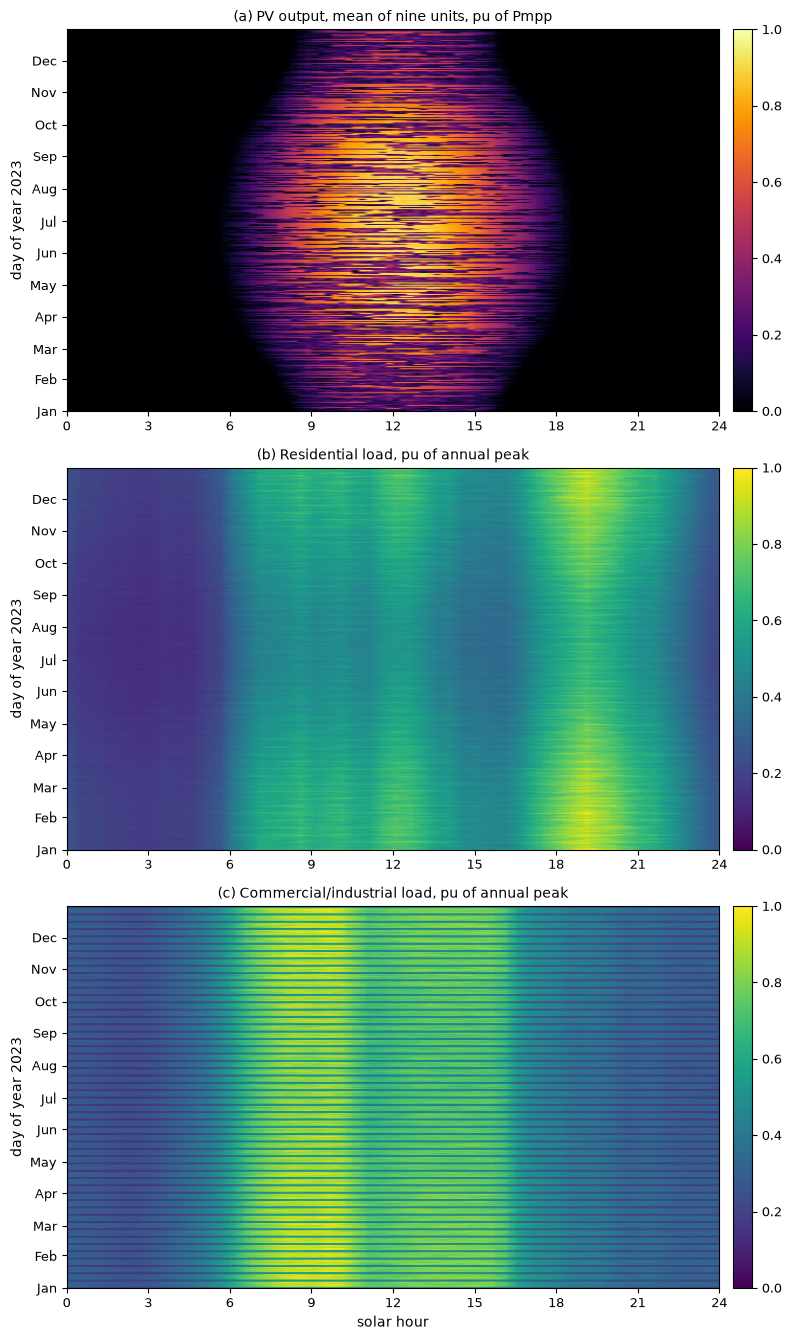

In [5]:
def day_hour(series):
    return series.values.reshape(365, int(24 / dt_h))

fig, axes = plt.subplots(3, 1, figsize=(8, 13.5))
for ax, z, title, cmap in zip(
        axes, (day_hour(pv_mean), day_hour(loads.residential), day_hour(loads.commercial_industrial)),
        ("(a) PV output, mean of nine units, pu of Pmpp", "(b) Residential load, pu of annual peak",
         "(c) Commercial/industrial load, pu of annual peak"), ("inferno", "viridis", "viridis")):
    im = ax.imshow(z, aspect="auto", origin="lower", extent=[0, 24, 1, 365], cmap=cmap, vmin=0, vmax=1)
    ax.set_xticks(range(0, 25, 3)); ax.set_title(title)
    ax.set_yticks(MONTH_START); ax.set_yticklabels(MONTHS); ax.set_ylabel(f"day of year {YEAR}")
    fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
axes[2].set_xlabel("solar hour")
plt.tight_layout(); plt.show()

Two daily series over the year: (a) the daily PV energy of the mean unit against its
clear-sky value, where the gap between the two is the cloud model and the clear days
touch the envelope; (b) the daily peak and daily minimum of the total network load in pu
of its annual peak (the two sectors weighted by their peak MW), whose weekend dips and
seasonal swing are the load-side inputs of the overvoltage question.

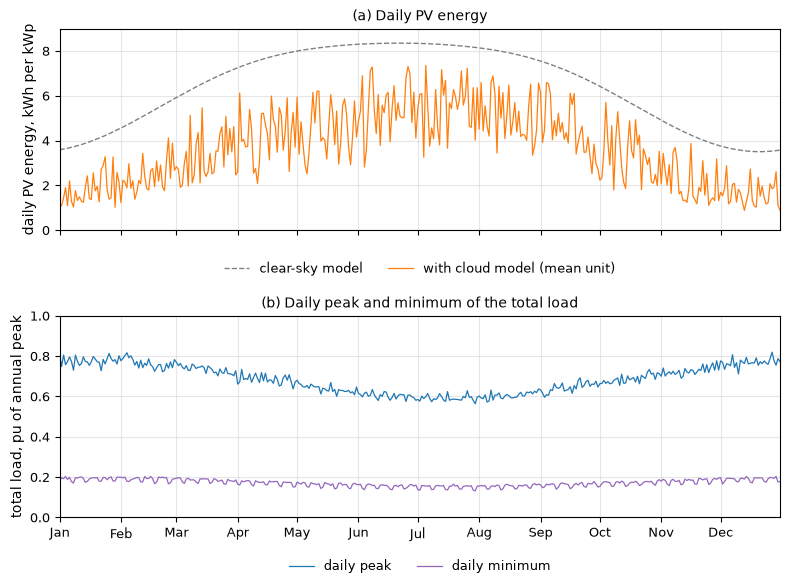

total load: annual peak 0.820 pu on 2023-12-27 19:00:00, minimum 0.132 pu on 2023-07-30 02:30:00, mean 0.455; daily minimum below 0.20 pu on 354 days


In [6]:
load_tot = pd.Series(total_pu(loads.residential.values, loads.commercial_industrial.values), index=loads.index)
d_cs = parts.clear_sky.resample("D").sum() * dt_h
d_load_max, d_load_min = load_tot.resample("D").max(), load_tot.resample("D").min()

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
ax = axes[0]
ax.plot(d_cs.index, d_cs.values, color="0.5", lw=1, ls="--", label="clear-sky model")
ax.plot(daily.index, daily.values, color="tab:orange", lw=0.9, label="with cloud model (mean unit)")
ax.set_ylabel("daily PV energy, kWh per kWp"); ax.set_ylim(0, 9); ax.grid(alpha=0.3)
ax.set_title("(a) Daily PV energy")
legend_below(ax, ncol=2, dy=-0.1)
ax = axes[1]
ax.plot(d_load_max.index, d_load_max.values, color="tab:blue", lw=0.9, label="daily peak")
ax.plot(d_load_min.index, d_load_min.values, color="tab:purple", lw=0.9, label="daily minimum")
ax.set_ylabel("total load, pu of annual peak"); ax.set_ylim(0, 1.0); ax.grid(alpha=0.3)
ax.set_title("(b) Daily peak and minimum of the total load")
ax.set_xlim(pd.Timestamp(f"{YEAR}-01-01"), pd.Timestamp(f"{YEAR}-12-31"))
ax.set_xticks(MONTH_DATES); ax.set_xticklabels(MONTHS)
legend_below(ax, ncol=2, dy=-0.15)
plt.tight_layout(); plt.show()

print(f"total load: annual peak {load_tot.max():.3f} pu on {load_tot.idxmax()}, minimum {load_tot.min():.3f} pu on {load_tot.idxmin()}, "
      f"mean {load_tot.mean():.3f}; daily minimum below 0.20 pu on {(d_load_min < 0.20).sum()} days")

## 5. Screening at unity power factor

The circuit of notebook 02 is built once: radial feeder 1, TR1 at +4.375 %, TR2 at its
brochure tap, the nine PV units of `cigre_dss.PV_KW` with an inverter rating of
1.1 $P_\mathrm{mpp}$ at unity power factor. At each of the 35,040 steps the two load
sectors are scaled to their profile values, each PV unit gets its own irradiance, and the
snapshot is solved with `cd.solve()`, which also re-holds bus 0 at exactly 110 kV. The
maximum and minimum voltage of feeder 1 (buses 1 to 11), the bus where the maximum occurs,
the active power at the feeder head (segment 1, bus 1 towards bus 2) and at the HV side
of TR1 are recorded. A single solve takes well under a millisecond, so the full year is run
without subsampling; the elapsed time is printed.

The first cell repeats the year without any PV. Notebook 02 chose the tap so that the
feeder without PV stays inside the band at the two extremes of the brochure day; the year
adds the seasonal and weekend factors and the noise, so its extremes are wider, and the
check confirms that even those stay inside 0.95 to 1.05 pu. Every violation hour of the
PV pass is then attributable to PV.

In [7]:
T = len(pv)
res_v, ci_v, pv_v = loads.residential.values, loads.commercial_industrial.values, pv.values
F1 = list(range(1, 12))

cd.build_circuit(tr1_tap_pct=TR1_TAP)
t0 = time.perf_counter()
v_lo, v_hi = np.empty(T), np.empty(T)
for i in range(T):
    cd.scale_loads(res_v[i], ci_v[i]); cd.solve(); v = cd.bus_voltages_pu()
    v_lo[i], v_hi[i] = min(v[b] for b in F1), max(v[b] for b in F1)
assert v_lo.min() >= 0.95 and v_hi.max() <= 1.05
print(f"no PV, TR1 tap +{TR1_TAP} %: feeder-1 voltage stays within {v_lo.min():.4f} to {v_hi.max():.4f} pu "
      f"over all {T} steps of the year ({time.perf_counter() - t0:.0f} s)")

no PV, TR1 tap +4.375 %: feeder-1 voltage stays within 0.9620 to 1.0409 pu over all 35040 steps of the year (19 s)


In [8]:
cd.build_circuit(tr1_tap_pct=TR1_TAP)
cd.add_pv(cd.PV_KW)                     # unity pf, kva = 1.1 * kW
vmax = np.empty(T); vmin = np.empty(T); bmax = np.empty(T, dtype=np.int16)
p_head = np.empty(T); p_tr1 = np.empty(T)
t0 = time.perf_counter()
for i in range(T):
    cd.scale_loads(res_v[i], ci_v[i])
    cd.set_pv_irradiances({b: pv_v[i, j] for j, b in enumerate(PV_BUSES)})
    cd.solve()
    v = cd.bus_voltages_pu()
    vf = [v[b] for b in F1]
    k = int(np.argmax(vf))
    vmax[i], bmax[i], vmin[i] = vf[k], F1[k], min(vf)
    p_head[i] = cd.line_pq(1)[0]
    p_tr1[i] = cd.transformer_results()["TR1"]["p_hv_mw"]
elapsed = time.perf_counter() - t0
screen = pd.DataFrame(dict(vmax=vmax, bmax=bmax, vmin=vmin, p_head_mw=p_head, p_tr1_mw=p_tr1), index=pv.index)
print(f"PV at unity pf: {T} snapshots solved in {elapsed:.0f} s ({elapsed / T * 1e3:.2f} ms per step)")

def hours(mask):
    return float(mask.sum() * dt_h)
over = screen.vmax > 1.05
hours_over = hours(over)
d_vmax = screen.vmax.resample("D").max()
d_pv = pv_mean.resample("D").max()
print(f"\nmax feeder-1 voltage   {screen.vmax.max():.4f} pu at {screen.vmax.idxmax()}, bus {screen.bmax[screen.vmax.idxmax()]}")
print(f"min feeder-1 voltage   {screen.vmin.min():.4f} pu at {screen.vmin.idxmin()}")
print(f"hours above 1.05 pu    {hours_over:.2f} h ({hours_over / 8760:.2%} of the year), on {(d_vmax > 1.05).sum()} days; "
      f"hours below 0.95 pu {hours(screen.vmin < 0.95):.2f} h")
print(f"reverse flow at the feeder head (segment 1): {hours(screen.p_head_mw < 0):.0f} h; "
      f"TR1 HV-side P always positive: {'yes' if (screen.p_tr1_mw > 0).all() else 'no'} "
      f"(minimum {screen.p_tr1_mw.min():.2f} MW)")
print("bus carrying the maximum during the violation steps:",
      ", ".join(f"bus {b}: {n * dt_h:.2f} h" for b, n in screen.bmax[over].value_counts().items()))
m_over = over.resample("ME").sum() * dt_h
print("hours above 1.05 pu per month:", ", ".join(f"{m} {v:.1f}" for m, v in zip(MONTHS, m_over.values)))

PV at unity pf: 35040 snapshots solved in 23 s (0.65 ms per step)

max feeder-1 voltage   1.0637 pu at 2023-07-22 11:00:00, bus 11
min feeder-1 voltage   0.9620 pu at 2023-12-27 19:00:00
hours above 1.05 pu    199.75 h (2.28% of the year), on 118 days; hours below 0.95 pu 0.00 h
reverse flow at the feeder head (segment 1): 1410 h; TR1 HV-side P always positive: yes (minimum 3.19 MW)
bus carrying the maximum during the violation steps: bus 7: 147.50 h, bus 11: 52.25 h
hours above 1.05 pu per month: Jan 0.0, Feb 0.0, Mar 0.0, Apr 12.0, May 13.0, Jun 46.0, Jul 61.2, Aug 49.8, Sep 17.8, Oct 0.0, Nov 0.0, Dec 0.0


**Two days for daily plots.** The controllers of the next notebook are compared on the
year as a whole, but two days are also plotted hour by hour:

- the **worst day**: the day with the highest per-step maximum voltage of the year;
- a **typical sunny day**: among the days whose PV peak (mean unit) exceeds 0.5 pu, the
  one whose daily maximum voltage is the median.

The second one matters because a controller that only fixes the worst day is of limited
interest; it should also behave well, and cost little reactive energy, on an ordinary
sunny day.

In [9]:
DAY_WORST = d_vmax.idxmax().date()
sunny = d_vmax[d_pv > 0.5]
DAY_TYPICAL = (sunny - sunny.median()).abs().idxmin().date()
for lab, day in (("worst day  ", DAY_WORST), ("typical day", DAY_TYPICAL)):
    s = screen.loc[str(day)]
    print(f"{lab}: {day} ({pd.Timestamp(day).day_name()}), daily max {d_vmax[str(day)]:.4f} pu at bus {int(s.bmax[s.vmax.idxmax()])}, "
          f"PV peak {d_pv[str(day)]:.3f} pu, midday total load {load_tot.loc[str(day)].between_time('11:00', '14:00').mean():.3f} pu of peak, "
          f"{(s.vmax > 1.05).sum() * dt_h:.2f} h above 1.05 pu")
print(f"(median daily maximum of the {len(sunny)} days with PV peak > 0.5 pu: {sunny.median():.4f} pu; "
      f"{(sunny > 1.05).sum()} of them exceed 1.05 pu)")

worst day  : 2023-07-22 (Saturday), daily max 1.0637 pu at bus 11, PV peak 0.932 pu, midday total load 0.478 pu of peak, 2.75 h above 1.05 pu
typical day: 2023-09-14 (Thursday), daily max 1.0469 pu at bus 7, PV peak 0.801 pu, midday total load 0.567 pu of peak, 0.00 h above 1.05 pu
(median daily maximum of the 296 days with PV peak > 0.5 pu: 1.0470 pu; 118 of them exceed 1.05 pu)


The screening in three views: (a) the duration curve of the per-step maximum feeder-1
voltage, i.e. the values sorted from the highest downwards against the number of hours,
with the hours above 1.05 pu marked; (b) the daily maximum through the year with the two
selected days; (c) the histogram of the per-step maximum on a logarithmic count axis. The
bulk of the distribution is bus 1, the transformer secondary, moving with the load between
about 1.01 and 1.04 pu; PV adds the tail beyond that at midday on clear days.

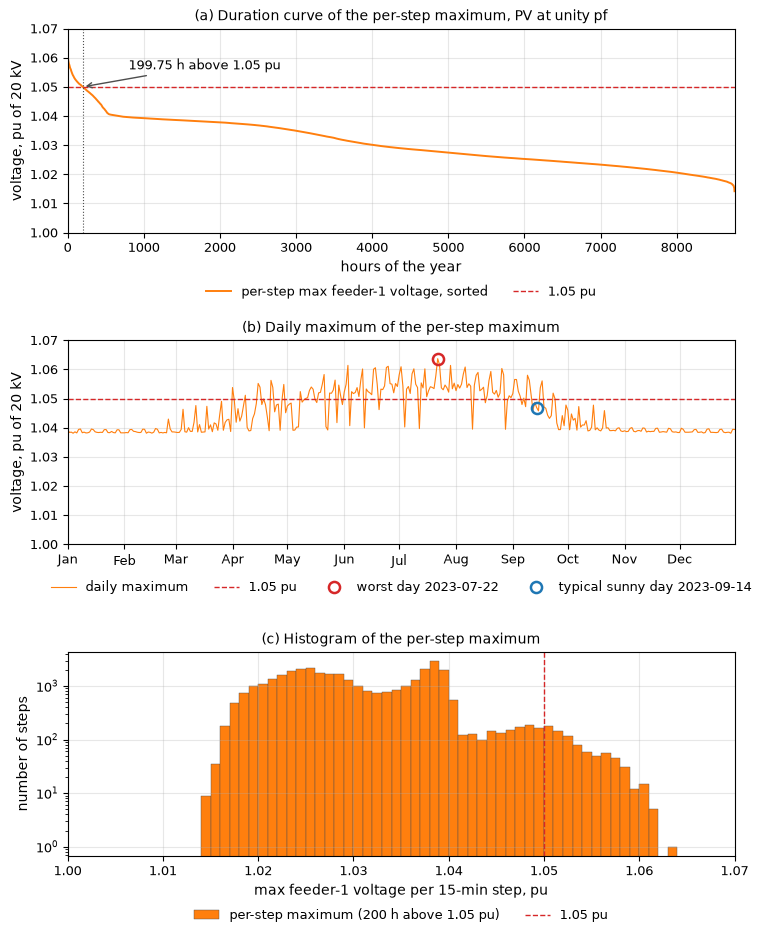

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(8, 9.5))
ax = axes[0]
dur = np.sort(screen.vmax.values)[::-1]
hrs = np.arange(1, T + 1) * dt_h
ax.plot(hrs, dur, color="tab:orange", lw=1.4, label="per-step max feeder-1 voltage, sorted")
ax.axhline(1.05, color="tab:red", lw=1, ls="--", label="1.05 pu")
ax.axvline(hours_over, color="0.3", lw=0.8, ls=":")
ax.annotate(f"{hours_over:.2f} h above 1.05 pu", xy=(hours_over, 1.05), xytext=(hours_over + 600, 1.056),
            fontsize=9, arrowprops=dict(arrowstyle="->", color="0.3"))
ax.set_xlim(0, 8760); ax.set_ylim(1.00, 1.07); ax.set_xlabel("hours of the year"); ax.set_ylabel("voltage, pu of 20 kV")
ax.grid(alpha=0.3); ax.set_title("(a) Duration curve of the per-step maximum, PV at unity pf")
legend_below(ax, ncol=2, dy=-0.2)

ax = axes[1]
ax.plot(d_vmax.index, d_vmax.values, lw=0.8, color="tab:orange", label="daily maximum")
ax.axhline(1.05, color="tab:red", lw=1, ls="--", label="1.05 pu")
for day, lab, c in ((DAY_WORST, "worst day", "tab:red"), (DAY_TYPICAL, "typical sunny day", "tab:blue")):
    ax.plot(pd.Timestamp(day), d_vmax[str(day)], "o", color=c, ms=8, mfc="none", mew=1.8, label=f"{lab} {day}")
ax.set_xlim(pd.Timestamp(f"{YEAR}-01-01"), pd.Timestamp(f"{YEAR}-12-31")); ax.set_ylim(1.00, 1.07)
ax.set_xticks(MONTH_DATES); ax.set_xticklabels(MONTHS)
ax.set_ylabel("voltage, pu of 20 kV"); ax.grid(alpha=0.3); ax.set_title("(b) Daily maximum of the per-step maximum")
legend_below(ax, ncol=4, dy=-0.12)

ax = axes[2]
bins = np.arange(1.000, 1.071, 0.001)
ax.hist(screen.vmax, bins=bins, color="tab:orange", edgecolor="0.3", lw=0.3, label=f"per-step maximum ({hours_over:.0f} h above 1.05 pu)")
ax.axvline(1.05, color="tab:red", lw=1, ls="--", label="1.05 pu")
ax.set_yscale("log"); ax.set_xlim(1.00, 1.07); ax.set_xlabel("max feeder-1 voltage per 15-min step, pu"); ax.set_ylabel("number of steps")
ax.grid(alpha=0.3); ax.set_title("(c) Histogram of the per-step maximum")
legend_below(ax, ncol=2, dy=-0.2)
plt.tight_layout(); plt.show()

The two selected days hour by hour. Panels (a) and (c): PV output (mean of the nine units)
and the two load sectors in pu; panels (b) and (d): the maximum and minimum feeder-1
voltage with the 0.95 to 1.05 pu band, the excursion above 1.05 pu shaded. The line
styles of (c) and (d) are those of (a) and (b).

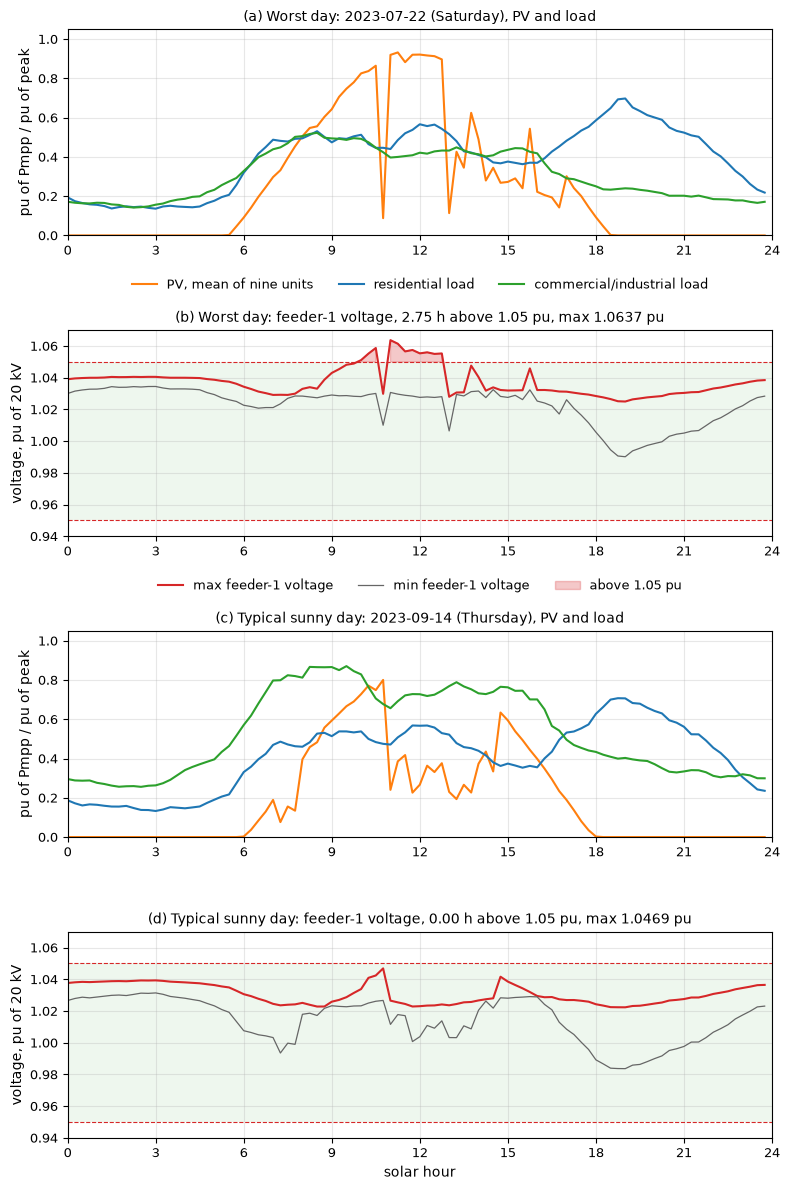

In [11]:
fig, axes = plt.subplots(4, 1, figsize=(8, 12))
for j, (day, lab) in enumerate(((DAY_WORST, "Worst day"), (DAY_TYPICAL, "Typical sunny day"))):
    p = pv.loc[str(day)].mean(axis=1); l = loads.loc[str(day)]; s = screen.loc[str(day)]
    ax = axes[2 * j]
    ax.plot(h, p, color="tab:orange", label="PV, mean of nine units")
    ax.plot(h, l.residential, color="tab:blue", label="residential load")
    ax.plot(h, l.commercial_industrial, color="tab:green", label="commercial/industrial load")
    ax.set_xlim(0, 24); ax.set_xticks(range(0, 25, 3)); ax.set_ylim(0, 1.05); ax.set_ylabel("pu of Pmpp / pu of peak"); ax.grid(alpha=0.3)
    ax.set_title(f"({'ac'[j]}) {lab}: {day} ({pd.Timestamp(day).day_name()}), PV and load")
    ax = axes[2 * j + 1]
    ax.axhspan(0.95, 1.05, color="tab:green", alpha=0.08, lw=0)
    ax.plot(h, s.vmax, color="tab:red", label="max feeder-1 voltage")
    ax.plot(h, s.vmin, color="0.4", lw=0.9, label="min feeder-1 voltage")
    ax.fill_between(h, 1.05, s.vmax, where=s.vmax > 1.05, color="tab:red", alpha=0.25, label="above 1.05 pu")
    ax.axhline(1.05, color="tab:red", lw=0.8, ls="--"); ax.axhline(0.95, color="tab:red", lw=0.8, ls="--")
    ax.set_xlim(0, 24); ax.set_xticks(range(0, 25, 3)); ax.set_ylim(0.94, 1.07)
    ax.set_ylabel("voltage, pu of 20 kV"); ax.grid(alpha=0.3)
    ax.set_title(f"({'bd'[j]}) {lab}: feeder-1 voltage, {(s.vmax > 1.05).sum() * dt_h:.2f} h above 1.05 pu, max {s.vmax.max():.4f} pu")
axes[3].set_xlabel("solar hour")
legend_below(axes[0], ncol=3, dy=-0.15)
legend_below(axes[1], ncol=3, dy=-0.15)
plt.tight_layout(); plt.show()

Where the violation hours fall: (a) per month, and (b) which bus carries the feeder
maximum during the steps above 1.05 pu. Bus 7 is the end of the lateral fed through
bus 8 and bus 11 the end of the main lateral 3-8-9-10-11, the two far ends of feeder 1
identified in notebook 02.

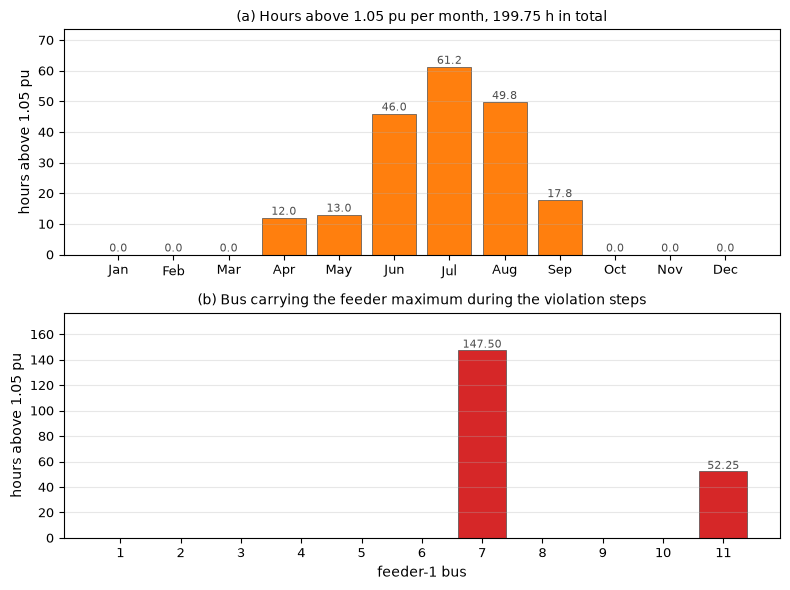

In [12]:
bus_h = pd.Series({b: hours(over & (screen.bmax == b)) for b in F1})
fig, axes = plt.subplots(2, 1, figsize=(8, 6))
ax = axes[0]
ax.bar(np.arange(12), m_over.values, color="tab:orange", edgecolor="0.3", lw=0.5)
for i, v in enumerate(m_over.values):
    ax.text(i, v + 1, f"{v:.1f}", ha="center", fontsize=8, color="0.3")
ax.set_xticks(np.arange(12)); ax.set_xticklabels(MONTHS); ax.set_ylabel("hours above 1.05 pu")
ax.set_ylim(0, m_over.max() * 1.2); ax.grid(axis="y", alpha=0.3)
ax.set_title(f"(a) Hours above 1.05 pu per month, {hours_over:.2f} h in total")
ax = axes[1]
ax.bar([str(b) for b in F1], bus_h.values, color=["tab:red" if v > 0 else "0.7" for v in bus_h.values], edgecolor="0.3", lw=0.5)
for i, v in enumerate(bus_h.values):
    if v > 0:
        ax.text(i, v + 2, f"{v:.2f}", ha="center", fontsize=8, color="0.3")
ax.set_xlabel("feeder-1 bus"); ax.set_ylabel("hours above 1.05 pu"); ax.set_ylim(0, bus_h.max() * 1.2); ax.grid(axis="y", alpha=0.3)
ax.set_title("(b) Bus carrying the feeder maximum during the violation steps")
plt.tight_layout(); plt.show()

## 6. Save the selected days and the screening series

`screening_2023.h5` holds the per-step series of the unity-pf pass (`time`, `vmax`,
`bmax`, `vmin`, `p_head_mw`, `p_tr1_mw`) and the two selected days as file attributes
(date string and 0-based day index into the year). The selected days and the headline
numbers are also written to `selected_days_2023.json` so that later notebooks can read
them without opening the HDF5 file.

In [13]:
day_index = lambda day: (pd.Timestamp(day) - pd.Timestamp(year=YEAR, month=1, day=1)).days
sel = dict(worst_day=str(DAY_WORST), worst_day_index=int(day_index(DAY_WORST)),
           typical_day=str(DAY_TYPICAL), typical_day_index=int(day_index(DAY_TYPICAL)),
           clear_day=str(DAY_CLEAR), cloudy_day=str(DAY_CLOUDY),
           hours_over_1p05_unity_pf=hours_over, vmax_year=float(screen.vmax.max()),
           vmin_year=float(screen.vmin.min()), tr1_tap_pct=TR1_TAP,
           steps_per_day=int(24 / dt_h), year=YEAR, seed=SEED)
with h5py.File("screening_2023.h5", "w") as f:
    f.create_dataset("time", data=(screen.index.asi8 // 10 ** 9).astype(np.int64))
    for c in screen.columns:
        f.create_dataset(c, data=screen[c].values, compression="gzip")
    f["vmax"].attrs["description"] = f"max voltage of feeder-1 buses 1..11, pu of 20 kV, PV at unity pf, no control, TR1 tap +{TR1_TAP} %"
    f["vmin"].attrs["description"] = "min voltage of feeder-1 buses 1..11, same case"
    f["p_head_mw"].attrs["description"] = "active power entering segment 1 at bus 1, MW (negative = reverse flow)"
    f["p_tr1_mw"].attrs["description"] = "active power at the HV side of TR1, MW"
    for k, v in sel.items():
        f.attrs[k] = v
with open("selected_days_2023.json", "w") as f:
    json.dump(sel, f, indent=2)
with h5py.File("screening_2023.h5", "r") as f:
    print("screening_2023.h5 datasets:", {k: f[k].shape for k in f})
print("selected_days_2023.json:", json.dumps(sel, indent=2))

screening_2023.h5 datasets: {'bmax': (35040,), 'p_head_mw': (35040,), 'p_tr1_mw': (35040,), 'time': (35040,), 'vmax': (35040,), 'vmin': (35040,)}
selected_days_2023.json: {
  "worst_day": "2023-07-22",
  "worst_day_index": 202,
  "typical_day": "2023-09-14",
  "typical_day_index": 256,
  "clear_day": "2023-07-05",
  "cloudy_day": "2023-06-04",
  "hours_over_1p05_unity_pf": 199.75,
  "vmax_year": 1.0636786610881632,
  "vmin_year": 0.961959419078122,
  "tr1_tap_pct": 4.375,
  "steps_per_day": 96,
  "year": 2023,
  "seed": 0
}


## 7. Summary

- `profiles.py` generates one year (2023, 15-minute steps, solar time, latitude 50 N) of
  PV output for the nine units and of residential and commercial/industrial load from a
  single seed and without any external data. The PV model is a Haurwitz clear-sky curve on
  a 30-degree south-facing plane multiplied by a two-state Markov cloud model with
  Beta-distributed attenuation, fast ramps and a winter-heavy cloudy fraction; the load
  model is the brochure's daily shapes with a seasonal swing, a weekend factor and
  smoothed 3 % noise. The year has an annual PV capacity factor of about 0.15 (about 1330
  kWh per kWp, the cloud model removing 43 % of the clear-sky yield; 61 % of the steps in
  the cloudy state) and load factors of about 0.45 (residential) and 0.48
  (commercial/industrial), with the residential peak in winter and the weekend ratios of
  1.05 and 0.60; the exact values are printed in step 3.
- The screening (step 5) solved every step of the year with the PV units at unity power
  factor in about 20 s. Without PV the feeder at the +4.375 % tap stays within the band
  all year (about 0.962 to 1.041 pu), so every violation hour is due to PV. With PV, the
  feeder exceeds 1.05 pu for about 200 h of the year, at midday on clear days from spring
  to early autumn, with the maximum of about 1.064 pu at bus 11; the maximum sits at
  bus 7 or bus 11, the two far ends of feeder 1, in every violation step. Nothing happens
  below 0.95 pu: the problem is purely an overvoltage one. TR1 as a whole never reverses,
  because of the lumped load at bus 1, but the feeder head does on every sunny day.
- Two days were selected and written to `selected_days_2023.json` and `screening_2023.h5`:
  the worst day, 2023-07-22, a clear Saturday in July on which full PV output meets the
  weekend load, and a typical sunny day, 2023-09-14, a Thursday with a PV peak of about
  0.8 pu whose daily maximum is the median of the 296 days with PV peak above 0.5 pu and
  lies just below 1.05 pu. The first shows what a controller has to remove, the second
  what it should leave alone.

The next notebook runs the same year with fixed volt-var controllers on the nine PV
units (standard droop curves with different dead bands and slopes) and compares them on
the overvoltage hours, the reactive energy and the losses of the year, with hour-by-hour
plots on the two selected days.

Files: `profiles.py` (models and HDF5 I/O), `cigre_dss.py`, `profiles_2023.h5`,
`screening_2023.h5`, `selected_days_2023.json` and this notebook.